# Проверка гипотез: t-критерий, Манна-Уитни, хи-квадрат

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('data/rgr2.csv', sep=';')
n = len(df)
df.head()

,X1,X2,X3,X4
0,71.89,45.92,77.38,17.77
1,56.12,40.40,64.31,30.18
2,58.48,49.30,78.72,1.10
3,60.93,37.47,92.11,17.83
4,48.68,37.53,94.28,0.59


Равенство средних X1 и X2

In [2]:
x1 = df['X1'].values
x2 = df['X2'].values

d1 = x1.var(ddof=1)
d2 = x2.var(ddof=1)
d = ((n - 1) * d1 + (n - 1) * d2) / (2 * n - 2)
t = (x1.mean() - x2.mean()) / np.sqrt(d * 2 / n)

print('средние', round(x1.mean(), 6), round(x2.mean(), 6))
print('дисперсии', round(d1, 6), round(d2, 6), 'объединенная', round(d, 6))
print('t набл', round(t, 6), 't крит', round(stats.t.ppf(0.975, 2 * n - 2), 6))
print(stats.ttest_ind(x1, x2))

средние 56.803505 49.844433
дисперсии 62.098863 56.169715 объединенная 59.134289
t набл 6.30235 t крит 1.972396
TtestResult(statistic=np.float64(6.302350048639532), pvalue=np.float64(1.9632150352564066e-09), df=np.float64(192.0))


Гипотеза о среднем X3, проверяем 86.80

In [3]:
x3 = df['X3'].values
mu0 = 86.8

s = x3.std(ddof=1)
h = (x3.mean() - mu0) / s * np.sqrt(n)

print(f'среднее {x3.mean():.4f}, S2 {x3.var(ddof=1):.4f}, S {s:.4f}')
print(f'h набл {h:.4f}, t крит {stats.t.ppf(0.975, n - 1):.4f}, p {2 * stats.t.sf(abs(h), n - 1):.5f}')

среднее 83.0835, S2 81.2618, S 9.0145
h набл -4.0605, t крит 1.9850, p 0.00010


Тот же вопрос про X1 и X2, но непараметрическим критерием

In [4]:
u = stats.mannwhitneyu(x1, x2, alternative='two-sided')

print('U', u.statistic)
print('p', u.pvalue)

U 6894.0
p 2.1658584241340633e-08


Согласие X4 с показательным распределением, лямбда = 0.053

In [5]:
x4 = df['X4'].values
lam = 0.053
k = int(1 + 3.322 * np.log10(n)) + 1
step = (x4.max() - x4.min()) / k

left = np.arange(k) * step
right = np.append(left[1:], np.inf)
obs = [((x4 >= a) & (x4 < b)).sum() for a, b in zip(left, right)]
exp = [n * (np.exp(-lam * a) - (np.exp(-lam * b) if np.isfinite(b) else 0)) for a, b in zip(left, right)]

print('интервалов', k, 'ширина', round(step, 3))
pd.DataFrame({'left': left.round(2), 'right': right.round(2), 'obs': obs, 'exp': np.round(exp, 2)})

интервалов 8 ширина 9.255


,left,right,obs,exp
0,0.00,9.25,36,37.61
1,9.25,18.51,25,23.03
2,18.51,27.76,11,14.10
3,27.76,37.02,9,8.63
4,37.02,46.27,6,5.29
5,46.27,55.53,2,3.24
6,55.53,64.78,7,1.98
7,64.78,inf,1,3.13


In [6]:
# три последних интервала объединяем, там ожидаемая частота меньше 5
o = np.array(obs[:5] + [sum(obs[5:])])
e = np.array(exp[:5] + [sum(exp[5:])])
chi = (((o - e) ** 2) / e).sum()
dof = len(o) - 1

print('наблюдаемые', o)
print('ожидаемые', e.round(2))
print('хи2 набл', round(chi, 3), 'хи2 крит', round(stats.chi2.ppf(0.95, dof), 2), 'при df =', dof)

наблюдаемые [36 25 11  9  6 10]
ожидаемые [37.61 23.03 14.1   8.63  5.29  8.35]
хи2 набл 1.358 хи2 крит 11.07 при df = 5


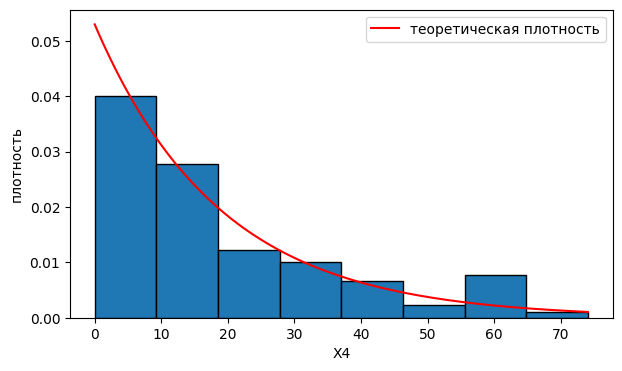

In [7]:
xs = np.linspace(0, x4.max(), 200)

plt.figure(figsize=(7, 4))
plt.hist(x4, bins=list(left) + [x4.max()], density=True, edgecolor='black')
plt.plot(xs, lam * np.exp(-lam * xs), color='red', label='теоретическая плотность')
plt.xlabel('X4')
plt.ylabel('плотность')
plt.legend()
plt.show()

X1 и X2: t = 6.30 против критического 1.97, средние различаются, Манна-Уитни говорит то же самое.

X3: h = -4.06, среднее 83.08 значимо меньше проверяемых 86.80.

Хи2 для X4 вышел 1.36 при критическом 11.07, с показательным законом данные не спорят